# 1. Setup
## 1.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


## 1.2 Combining 2 CSVs

In [2]:
# Combining both csvs
csv1 = "../archive/Credit_Card_Dataset_2025_Sept_1.csv"
csv2 = "../archive/Credit_Card_Dataset_2025_Sept_2.csv"
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)
df = pd.merge(df1, df2, left_on='ID', right_on='User', how='inner')
df = df.drop(columns=[df.columns[0], "ID", "User"])
df.head()

,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,Secondary / secondary special
1,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
2,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
3,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
4,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special


## 1.3 Overview of dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GENDER          25134 non-null  object 
 1   CAR             25134 non-null  object 
 2   REALITY         25134 non-null  object 
 3   NO_OF_CHILD     25134 non-null  int64  
 4   FAMILY_TYPE     25134 non-null  object 
 5   HOUSE_TYPE      25134 non-null  object 
 6   FLAG_MOBIL      25134 non-null  int64  
 7   WORK_PHONE      25134 non-null  int64  
 8   PHONE           25134 non-null  int64  
 9   E_MAIL          25134 non-null  int64  
 10  FAMILY SIZE     25133 non-null  float64
 11  BEGIN_MONTH     25134 non-null  int64  
 12  AGE             25134 non-null  int64  
 13  YEARS_EMPLOYED  25125 non-null  float64
 14  TARGET          25134 non-null  int64  
 15  INCOME          25134 non-null  float64
 16  INCOME_TYPE     25122 non-null  object 
 17  EDUCATION_TYPE  25134 non-null 

In [4]:
num_cols = ["NO_OF_CHILD", "BEGIN_MONTH", "AGE", "YEARS_EMPLOYED", "INCOME", "FAMILY SIZE" ]
cat_cols = ["TARGET", "GENDER", "CAR", "REALITY", "FAMILY_TYPE", "HOUSE_TYPE", "FLAG_MOBIL", "WORK_PHONE", "PHONE", "E_MAIL", "INCOME_TYPE", "EDUCATION_TYPE"]

In [5]:
summary_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

display(summary_table)

,Missing Values,Unique Values
GENDER,0,2
CAR,0,2
REALITY,0,2
NO_OF_CHILD,0,9
FAMILY_TYPE,0,5
HOUSE_TYPE,0,6
FLAG_MOBIL,0,1
WORK_PHONE,0,2
PHONE,0,2
E_MAIL,0,2


In [6]:
combined_counts = pd.concat(
    {
        col: df[col].value_counts()
        for col in cat_cols
    },
    axis=0
)

display(pd.DataFrame(combined_counts))

count
TARGET         0                              24712
               1                                422
GENDER         F                              15630
               M                               9504
CAR            N                              14618
               Y                              10516
REALITY        Y                              16461
               N                               8673
FAMILY_TYPE    Married                        17509
               Single / not married            3445
               Civil marriage                  2133
               Separated                       1467
               Widow                            580
HOUSE_TYPE     House / apartment              22102
               With parents                    1430
               Municipal apartment              812
               Rented apartment                 439
               Office apartment                 199
               Co-op apartment                  152
FLAG_MOBIL     1                              25134
WORK_PHONE     0                              18252
               1                               6882
PHONE          0                              17775
               1                               7359
E_MAIL         0                              22604
               1                               2530
INCOME_TYPE    Working                        15614
               Commercial associate            7050
               State servant                   2435
               Pensioner                         13
               Student                           10
EDUCATION_TYPE Secondary / secondary special  16808
               Higher education                7132
               Incomplete higher                993
               Lower secondary                  187
               Academic degree                   14

## 1.4 Data Cleaning

Filtering out: 
- Age > 100

Filling missing values:
- YEARS_EMPLOYED with median
- FAMILY SIZE with median
- INCOME_TYPE with mode

Droping columns:
- FLAG_MOBIL since it has only one category


In [7]:
df = df[df["AGE"] < 100]

df["YEARS_EMPLOYED"] = df["YEARS_EMPLOYED"].fillna(df["YEARS_EMPLOYED"].median())
df["FAMILY SIZE"] = df["FAMILY SIZE"].fillna(df["FAMILY SIZE"].median())

df["INCOME_TYPE"] = df["INCOME_TYPE"].fillna(df["INCOME_TYPE"].mode()[0])

# Drop FLAG_MOBIL since it has only 1 category
df = df.drop(columns=["FLAG_MOBIL"])
cat_cols.remove("FLAG_MOBIL")

print(" Remaining missing values:", df.isnull().sum().sum(), "Final shape:", df.shape)

 Remaining missing values: 0 Final shape: (25129, 17)


# 2 Visualization
## 2.1 Configuring plotting parameters

In [8]:
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'font.family': 'RobotoMono Nerd Font Mono',
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20,

    # Turn ticks ON
    'xtick.bottom': True,
    'ytick.left': True,

    # Tick direction & size
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,

    # Minor ticks visibility (important)
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,

    # Grid
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.axisbelow': True,
})

## 2.2 Configuring Axis

In [9]:
def style_ax(
    ax,
    minor_ticks=True,
    show_top=False,
    show_right=False,
    major_grid=True,
    minor_grid=True,
    major_grid_style=None,
    minor_grid_style=None
):
    # Default grid styles
    if major_grid_style is None:
        major_grid_style = dict(linestyle='-', linewidth=0.75, alpha=0.25)

    if minor_grid_style is None:
        minor_grid_style = dict(linestyle='-', linewidth=0.25, alpha=0.15)

    # Minor ticks
    if minor_ticks:
        ax.minorticks_on()

    # Tick visibility
    ax.tick_params(
        axis='both',
        which='both',
        top=show_top,
        right=show_right
    )

    # Major grid
    if major_grid:
        ax.grid(True, which='major', **major_grid_style)

    # Minor grid
    if minor_grid:
        ax.grid(True, which='minor', **minor_grid_style)

    return ax

## 2.3 Setting up plot function

In [10]:
def plot(
    plot_func,
    df=None,
    x=None,
    y=None,
    hue=None,
    data_arg=True,

    figsize=(10, 10),
    ax=None,

    # Labels
    title=None,
    x_label=None,
    y_label=None,

    # Legend
    show_legend=True,
    legend_title=None,
    legend_order=None,
    legend_ncol=None,
    legend_bbox=(0.5, 1.10),
    legend_markerscale=1.5,

    # Styling
    style=True,
    style_kwargs=None,

    # Export
    save_path=None,
    save_format="svg",
    dpi=300,
    transparent=True,

    **kwargs
):

    def to_title(text):
        return str(text).replace("_", " ").title() if text else None

    def reorder_legend(ax):
        handles, labels = ax.get_legend_handles_labels()

        if not handles:
            return

        order = legend_order if legend_order else list(range(len(handles)))

        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]

        ax.legend(
            handles,
            labels,
            loc='upper center',
            bbox_to_anchor=legend_bbox,
            ncol=legend_ncol if legend_ncol else len(order),
            frameon=False,
            markerscale=legend_markerscale
        )

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    plot_kwargs = dict(**kwargs)

    if data_arg and df is not None:
        plot_kwargs["data"] = df

    if x is not None:
        plot_kwargs["x"] = x

    if y is not None:
        plot_kwargs["y"] = y

    if hue is not None:
        plot_kwargs["hue"] = hue

    plot_kwargs["ax"] = ax

    plot_func(**plot_kwargs)

    if title:
        ax.set_title(to_title(title))

    if x_label or x:
        ax.set_xlabel(to_title(x_label if x_label else x))

    if y_label or y:
        ax.set_ylabel(to_title(y_label if y_label else y))

    leg = ax.get_legend()
    if leg:
        if show_legend:
            if legend_title or hue:
                leg.set_title(to_title(legend_title if legend_title else hue))
            reorder_legend(ax)
        else:
            leg.remove()

    if style:
        style_kwargs = style_kwargs or {}
        style_ax(ax, **style_kwargs)

    if save_path:
        fig.savefig(
            f"{save_path}/{to_title(x_label if x_label else x)} VS {to_title(y_label if y_label else y)} {"Transparent" if transparent else ""}.{save_format}",
            format=save_format,
            dpi=dpi,
            bbox_inches="tight",
            transparent=transparent
        )

    return ax

# 2.4 Analysis

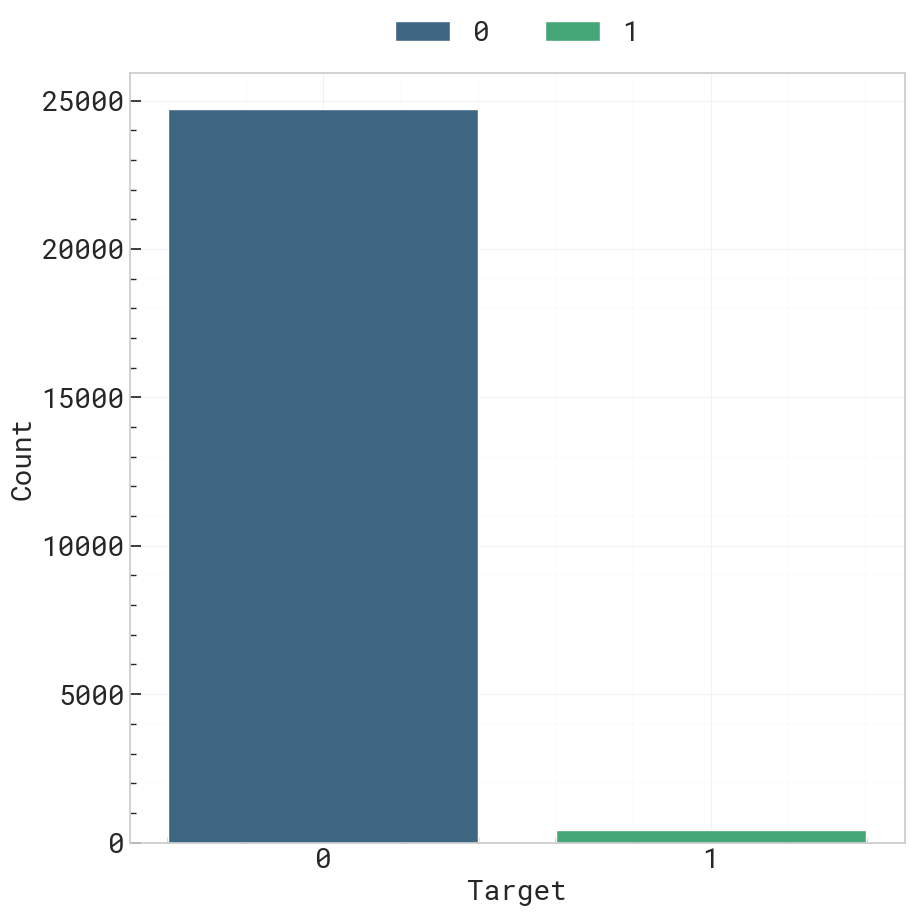

In [11]:
ax = plot(
    sns.countplot,
    df,
    x="TARGET",
    palette="viridis",
    x_label="TARGET",
    y_label="Count",
    hue = "TARGET",
    transparent=False,
    save_path="../exports/"
)

The number of "0" cases is 24712, while that of "1" cases is 422 a tiny fraction of that.

Therefore any machine learning model trained on this will need techniques like SMOTE or adjusted class weights.

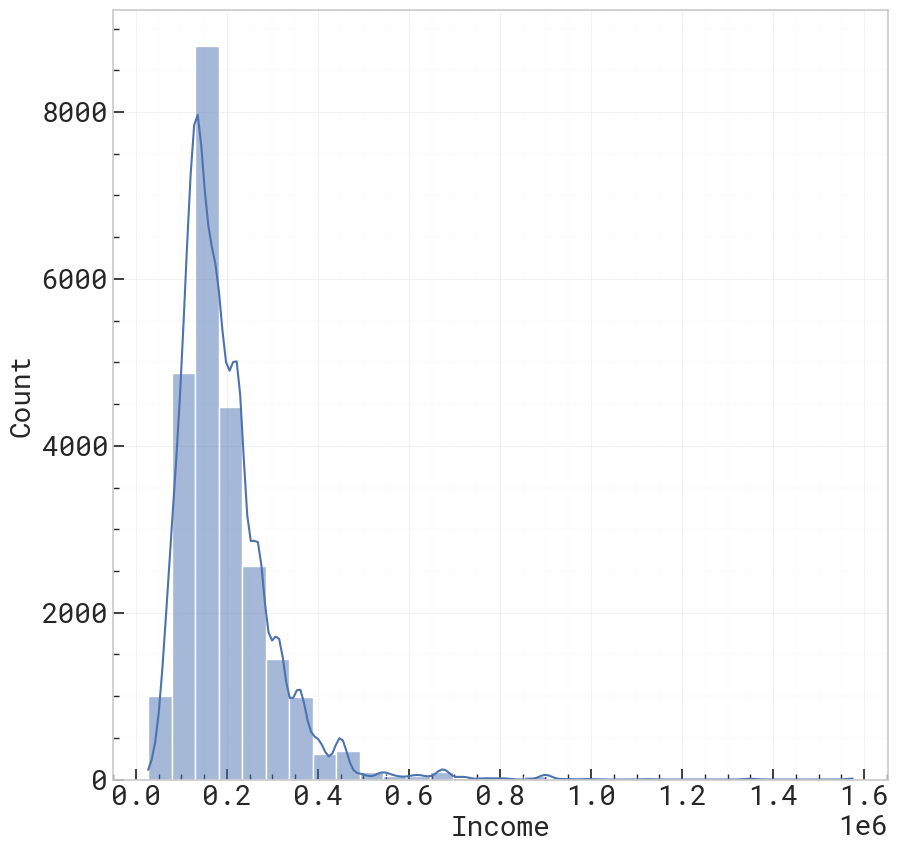

In [12]:
ax = plot(
    sns.histplot,
    df=df,
    x="INCOME",
    bins=30,
    kde=True,
    save_path="../exports/",
    transparent=False,
    style_kwargs={"minor_grid": True}
)

The histograms and KDE plot of `INCOME` is heavily right-skewed. Most applicants earn between 100k and 300k, with a long tail of "high earners".

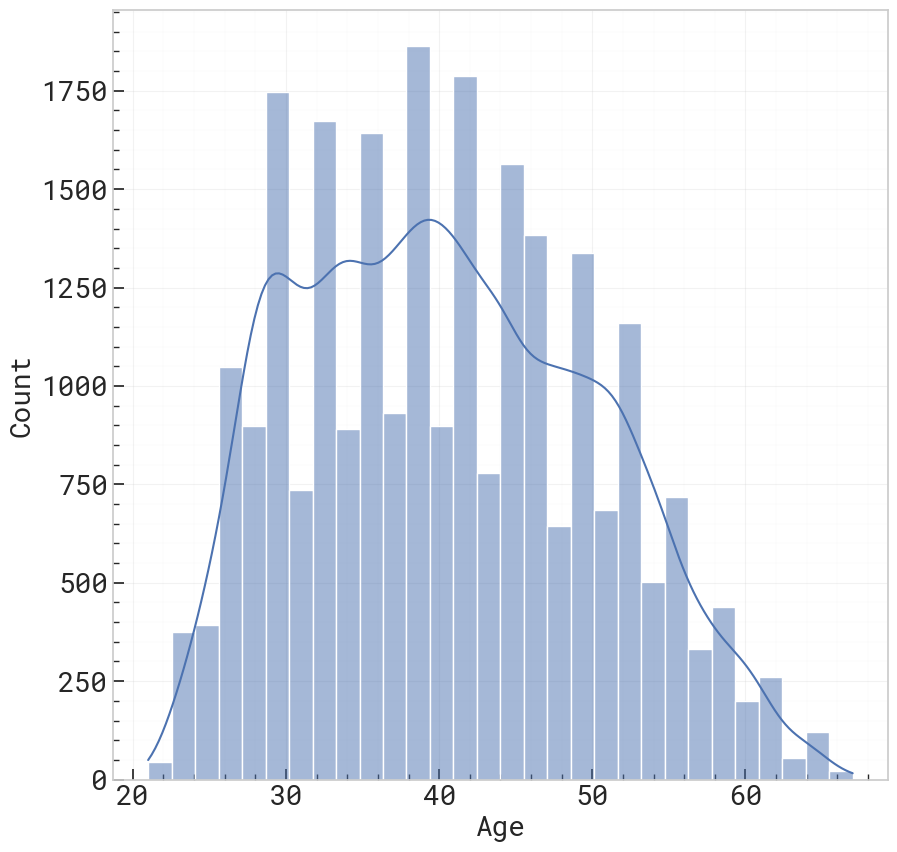

In [13]:
ax = plot(
    sns.histplot,
    df=df,
    x="AGE",
    bins=30,
    kde=True,
    transparent=False,
    save_path="../exports/"
)

This is more normally distributed (though slightly irregular), with the bulk of applicants falling between 30 and 50 years old. There is a noticeable dip around age 35 and a peak near age 40.

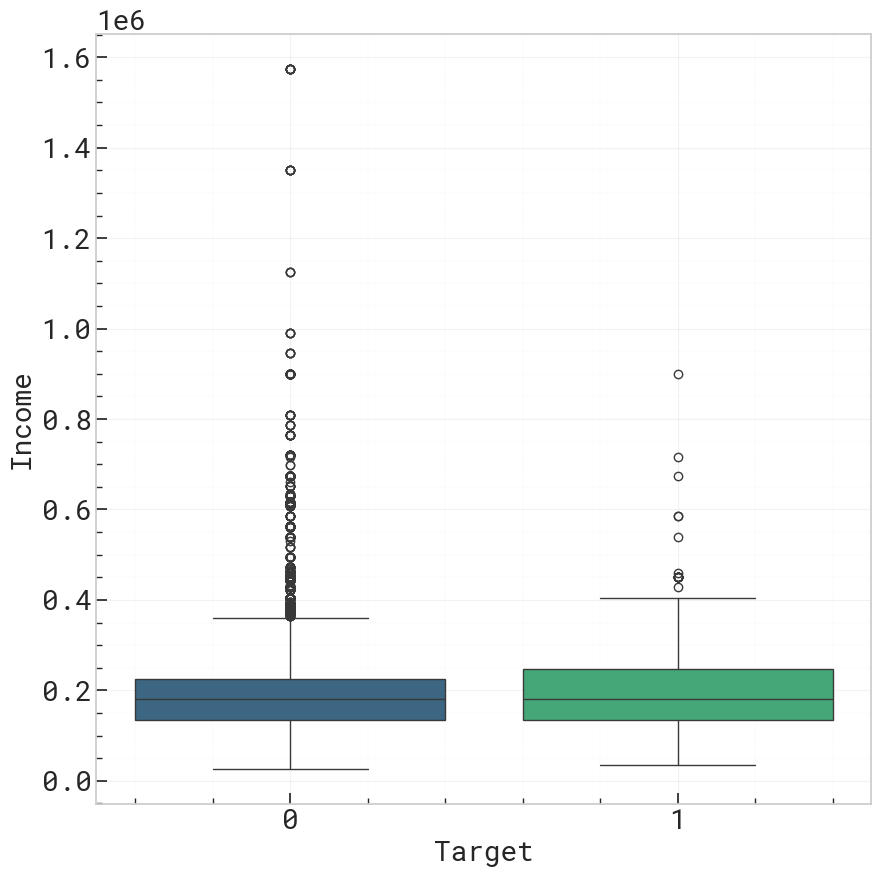

In [14]:
ax = plot(
    sns.boxplot,
    df=df,
    palette="viridis",
    x="TARGET",
    y="INCOME",
    hue="TARGET",
    show_legend=False,
    transparent=False,
    save_path="../exports/"
)

`INCOME`, does not seem to be a strong linear discriminator for the `TARGET`. The quartiles and interquartile ranges overlap almost perfectly. Hoever there are more outliers in the "0" case which could be due to the heavy class imbalance.

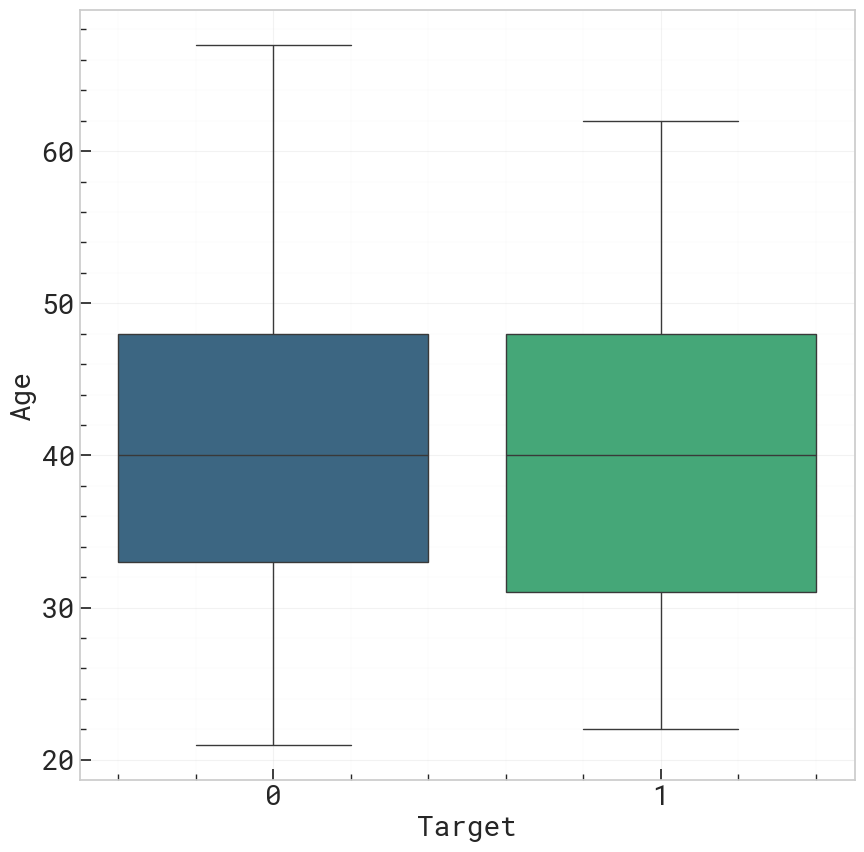

In [15]:
ax = plot(
    sns.boxplot,
    df=df,
    palette="viridis",
    x="TARGET",
    y="AGE",
    hue="TARGET",
    show_legend=False,
    transparent=False,
    save_path="../exports/"
)

`AGE`, does not seem to be a strong linear discriminator for the `TARGET`. The quartiles and interquartile ranges overlap almost perfectly.

<Axes: xlabel='Age', ylabel='Income'>

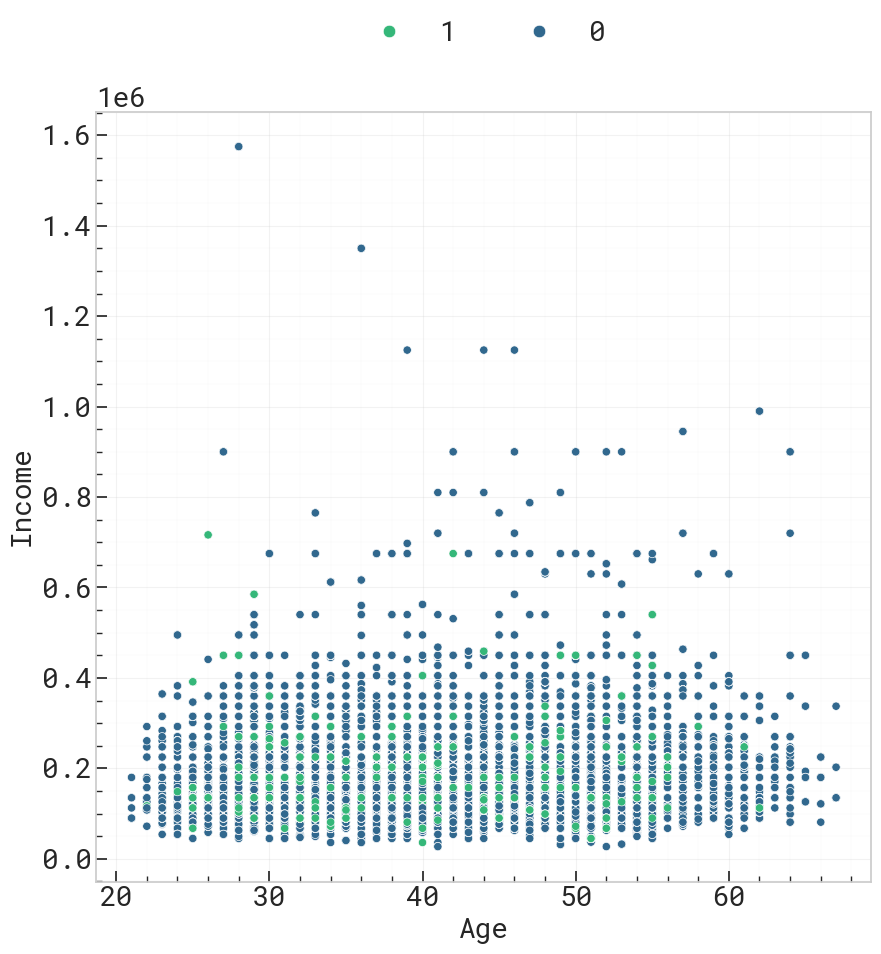

In [16]:
plot(
    sns.scatterplot,
    df=df,
    palette="viridis",
    x="AGE",
    y="INCOME",
    hue="TARGET",
    transparent=False,

    legend_order=[1, 0],     # reorder legend
    legend_ncol=2,           # horizontal layout
    legend_bbox=(0.5, 1.15), # move above plot

    save_path="../exports/",

    style_kwargs={
        "minor_grid": True
    }
)

There are very few defaults (green dots) among the "high income" outliers. This suggests that while age doesn't matter much, very high income might be a protective factor against defaulting.


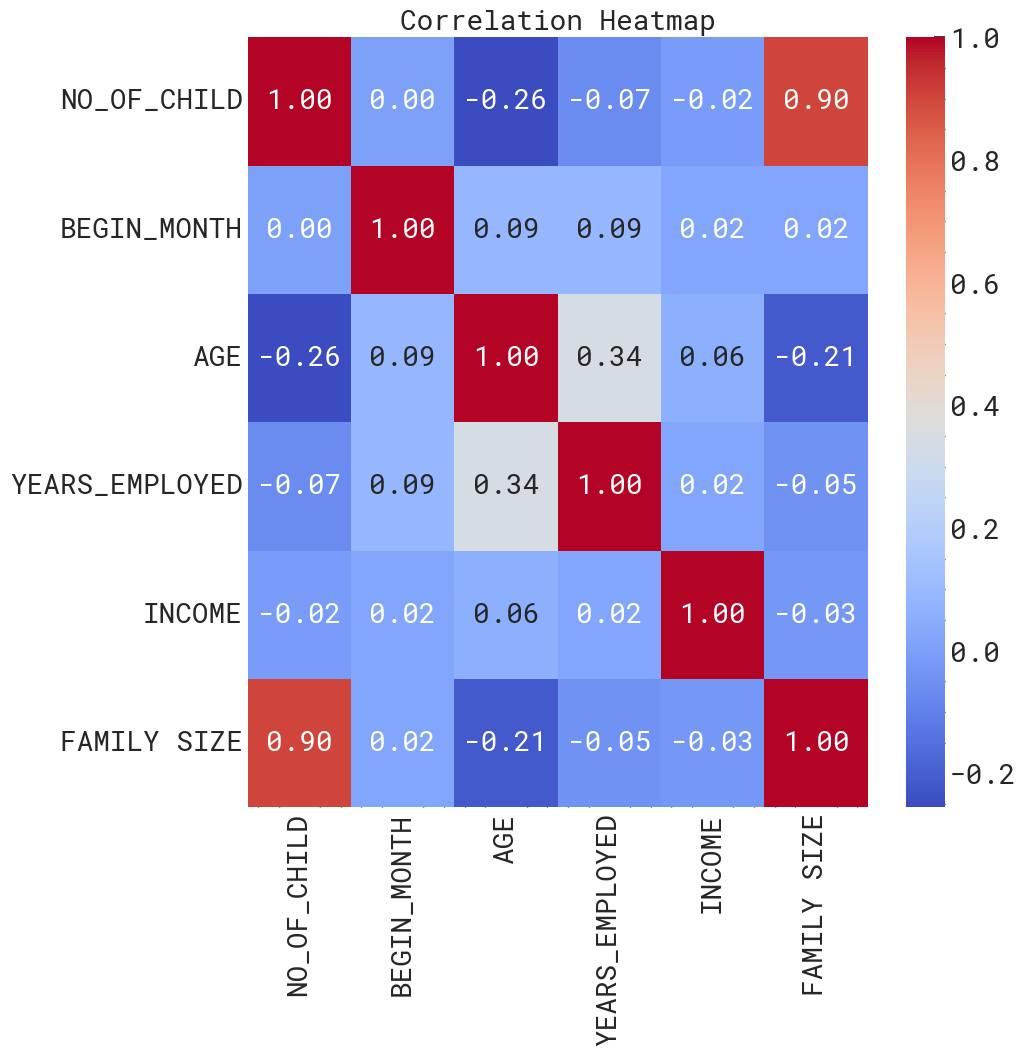

In [17]:
correlation_matrix = df[num_cols].corr()

ax = plot(
    sns.heatmap,
    df=None,
    data_arg=False,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    title="Correlation Heatmap",
    transparent=False,
    save_path="../exports/",
    **{"data": correlation_matrix}
)

The heatmap shows strong relationships between `AGE` and `YEARS_EMPLOYED` have a positive correlation of 0.34. This makes sense as older people have had more time to be in the workforce. Also `FAMILY SIZE` and `NO_OF_CHILD` show an obvious positive correlation of 0.9.

`NO_OF_CHILD` and `AGE` have a negative correlation of -0.26, suggesting younger applicants in this specific dataset tend to have more children listed.

Most variables have very low correlation with each other (near 0.00), meaning there isn't much redundancy (multicollinearity) between these specific features.

In [18]:
combined_table_pct = pd.concat(
    {
        col: pd.crosstab(df[col], df["TARGET"])
        for col in cat_cols if col != "TARGET"
    },
    axis=0
).round(2)

display(combined_table_pct)

chi2_summary = []

for col in [c for c in cat_cols if c != "TARGET"]:
    contingency_table = pd.crosstab(df[col], df['TARGET'])
    
    stat, p, dof, expected = chi2_contingency(contingency_table)
    
    chi2_summary.append({
        'Feature': col,
        'Chi-Square Statistic': round(stat, 4),
        'P-value': round(p, 4),
        'Degrees of Freedom': dof,
        'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'
    })

chi2_results_df = pd.DataFrame(chi2_summary).sort_values(by='P-value')

display(chi2_results_df.style.background_gradient(subset=['P-value'], cmap='Reds_r'))


TARGET                                            0    1
GENDER         F                              15397  230
               M                               9310  192
CAR            N                              14371  245
               Y                              10336  177
REALITY        N                               8492  179
               Y                              16215  243
FAMILY_TYPE    Civil marriage                  2101   32
               Married                        17227  277
               Separated                       1452   15
               Single / not married            3362   83
               Widow                            565   15
HOUSE_TYPE     Co-op apartment                  149    3
               House / apartment              21734  364
               Municipal apartment              792   19
               Office apartment                 194    5
               Rented apartment                 433    6
               With parents                    1405   25
WORK_PHONE     0                              17951  298
               1                               6756  124
PHONE          0                              17477  294
               1                               7230  128
E_MAIL         0                              22221  379
               1                               2486   43
INCOME_TYPE    Commercial associate            6931  119
               Pensioner                          0   13
               State servant                   2403   29
               Student                           10    0
               Working                        15363  261
EDUCATION_TYPE Academic degree                   14    0
               Higher education                7003  128
               Incomplete higher                972   21
               Lower secondary                  181    6
               Secondary / secondary special  16537  267

,Feature,Chi-Square Statistic,P-value,Degrees of Freedom,Significant (α=0.05)
8,INCOME_TYPE,764.789400,0.000000,4,Yes
2,REALITY,11.532900,0.000700,1,Yes
3,FAMILY_TYPE,19.248000,0.000700,4,Yes
0,GENDER,10.449400,0.001200,1,Yes
9,EDUCATION_TYPE,5.437900,0.245200,4,No
5,WORK_PHONE,0.768400,0.380700,1,No
4,HOUSE_TYPE,3.517600,0.620700,5,No
6,PHONE,0.180200,0.671200,1,No
7,E_MAIL,0.000000,0.996100,1,No
1,CAR,0.000000,1.000000,1,No


The table shows which categorical features are statistically "linked" to the `TARGET`.


`INCOME_TYPE`, `REALITY`, `FAMILY_TYPE`, and `GENDER` all have p-values $< 0.05$.